*AOI - Bounding Box taken for Guwahati Metropolitan Area.*

*Bands are downloaded using Sentinel-2 Harmonized Level-2A (SR) using Google Earth Engine*

# *Libraries Used*

In [47]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt



---



*read(value) - reads the no. of spectral bands

In [4]:
b2 = rasterio.open("/content/S2_Band2_Blue_2023.tif").read(1)
b3 = rasterio.open("/content/S2_Band3_Green_2023.tif").read(1)
b4 = rasterio.open("/content/S2_Band4_Red_2023.tif").read(1)
b8 = rasterio.open("/content/S2_Band8_NIR_2023.tif").read(1)
b11 = rasterio.open("/content/S2_Band11_SWIR_2023.tif").read(1)

*shape - Number of bands, height and width of entire Raster Grid

band = 1 not showing because previously used read(1)

In [5]:
b2.shape
b3.shape
b4.shape
b8.shape

(1168, 2072)



---



*Statistics can also be performed using Rasterio.*

In [6]:
b2_stat = np.min(b2), np.max(b2), np.mean(b2), np.std(b2)
b2_stat

(np.float64(227.5),
 np.float64(3720.0),
 np.float64(727.2068108041994),
 np.float64(214.56081218139553))

In [7]:
b3_stat = np.min(b3), np.max(b3), np.mean(b3), np.std(b3)
b3_stat

(np.float64(277.0),
 np.float64(4334.0),
 np.float64(863.0104388420955),
 np.float64(236.98829570940603))



---



# *Creating Maps*

4 band plotting together:

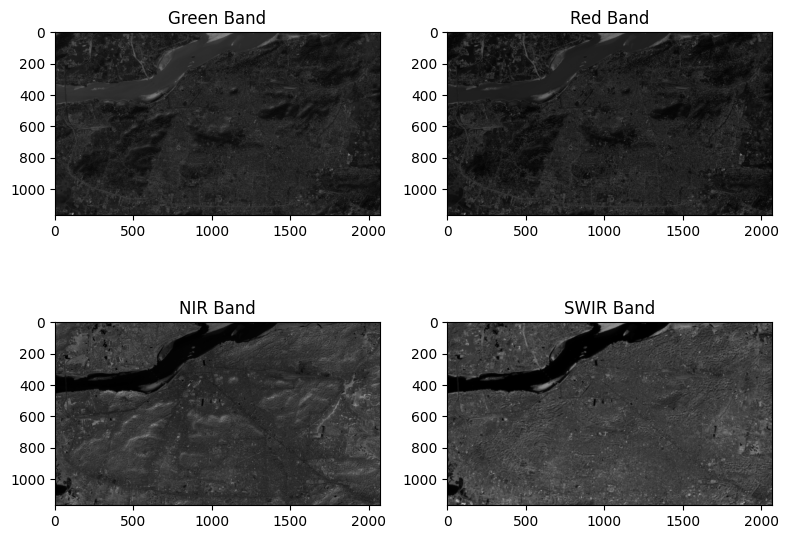

In [10]:
fig, ax = plt.subplots(2,2, figsize = (8,6))

ax[0,0].imshow(b3, cmap = 'gray')
ax[0,0].set_title("Green Band")

ax[0,1].imshow(b4, cmap = 'gray')
ax[0,1].set_title("Red Band")

ax[1,0].imshow(b8, cmap = 'gray')
ax[1,0].set_title("NIR Band")

ax[1,1].imshow(b11, cmap = 'gray')
ax[1,1].set_title("SWIR Band")

plt.tight_layout()
plt.show()



---



# **Calculation of Indices and Plotting**

**Normalized Difference Vegetation Index (NDVI)**

*(NIR-RED)/(NIR+RED)*

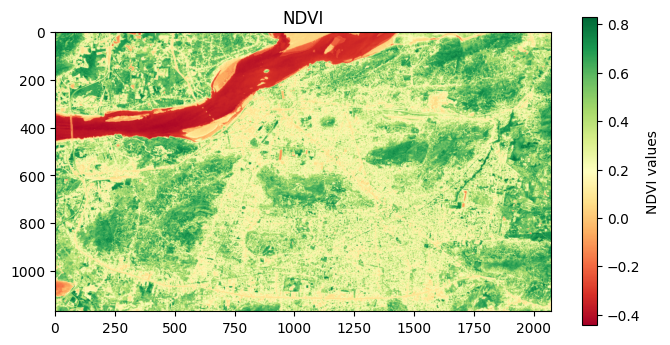

In [13]:
ndvi = (b8-b4)/(b8+b4)
plt.figure(figsize=(8,4))
plt.imshow(ndvi, cmap = 'RdYlGn')
plt.title("NDVI")
plt.colorbar(label="NDVI values")
plt.show()

**Extraction of Vegetation Content**

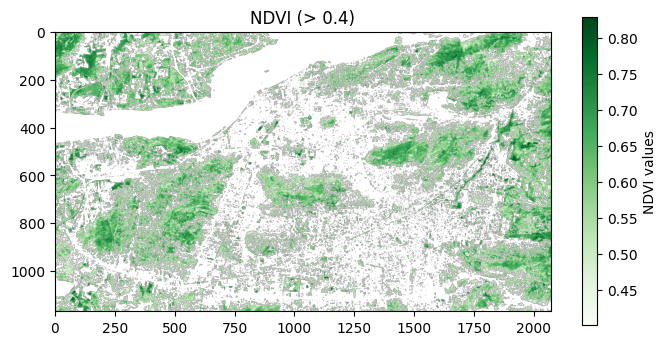

In [24]:
ndvi_masked = np.ma.masked_less_equal(ndvi, 0.4)
# 0.4 taken because Green vegetation is starting to show up after that range

plt.figure(figsize=(8, 4))
# imshow automatically handles masked arrays by making them transparent
plt.imshow(ndvi_masked, cmap='Greens')
plt.title("NDVI (> 0.4)")
plt.colorbar(label="NDVI values")
plt.show()

**Statistics:**

In [25]:
ndvi_mask = ndvi > 0.4

# 3. Count how many pixels meet the condition (True evaluates to 1, False to 0)
valid_pixel_count = np.sum(ndvi_mask)

# 4. Calculate the area
single_pixel_area = 10 * 10  # 10m * 10m = 100 m² for Sentinel-2
area_sq_meters = valid_pixel_count * single_pixel_area
area_hectares = area_sq_meters / 10000
area_sq_kilometers = area_sq_meters / 1e6

# 5. Print the results clearly
print(f"--- Area Calculation for NDVI > 0.4 ---")
print(f"Valid Pixels     : {valid_pixel_count:,}")
print(f"Square Meters    : {area_sq_meters:,.2f} m²")
print(f"Hectares         : {area_hectares:,.2f} ha")
print(f"Square Kilometers: {area_sq_kilometers:,.4f} km²")

--- Area Calculation for NDVI > 0.4 ---
Valid Pixels     : 1,014,170
Square Meters    : 101,417,000.00 m²
Hectares         : 10,141.70 ha
Square Kilometers: 101.4170 km²




---



**Normalized Difference Waterbody Index (NDWI)**

*(GREEN-NIR)/(GREEN+NIR)*

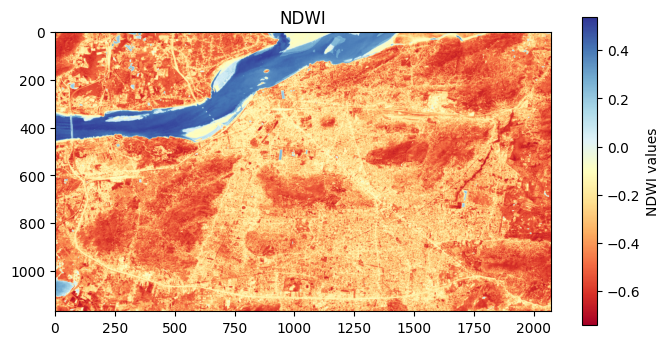

In [26]:
ndwi = (b3-b8)/(b3+b8)
plt.figure(figsize=(8,4))
plt.imshow(ndwi, cmap = 'RdYlBu')
plt.title("NDWI")
plt.colorbar(label="NDWI values")
plt.show()

**Extraction of Water Contents**

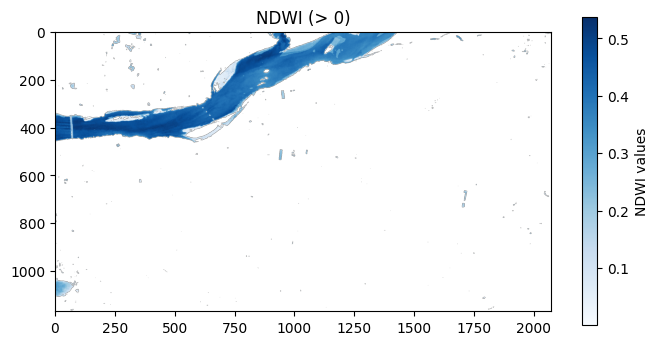

In [27]:
ndwi_masked = np.ma.masked_less_equal(ndwi, 0)
# 0 taken because Blue waterbody is starting to show up after that range

plt.figure(figsize=(8, 4))
# imshow automatically handles masked arrays by making them transparent
plt.imshow(ndwi_masked, cmap='Blues')
plt.title("NDWI (> 0)")
plt.colorbar(label="NDWI values")
plt.show()

**Statistics:**

In [28]:
ndwi_mask = ndwi > 0

# 3. Count how many pixels meet the condition (True evaluates to 1, False to 0)
valid_pixel_count = np.sum(ndwi_mask)

# 4. Calculate the area
single_pixel_area = 10 * 10  # 10m * 10m = 100 m² for Sentinel-2
area_sq_meters = valid_pixel_count * single_pixel_area
area_hectares = area_sq_meters / 10000
area_sq_kilometers = area_sq_meters / 1e6

# 5. Print the results clearly
print(f"--- Area Calculation for NDWI > 0 ---")
print(f"Valid Pixels     : {valid_pixel_count:,}")
print(f"Square Meters    : {area_sq_meters:,.2f} m²")
print(f"Hectares         : {area_hectares:,.2f} ha")
print(f"Square Kilometers: {area_sq_kilometers:,.4f} km²")

--- Area Calculation for NDWI > 0 ---
Valid Pixels     : 186,700
Square Meters    : 18,670,000.00 m²
Hectares         : 1,867.00 ha
Square Kilometers: 18.6700 km²




---



**Normalized Difference Built-up Index (NDBI)**

*(SWIR-NIR)/(SWIR+NIR)*

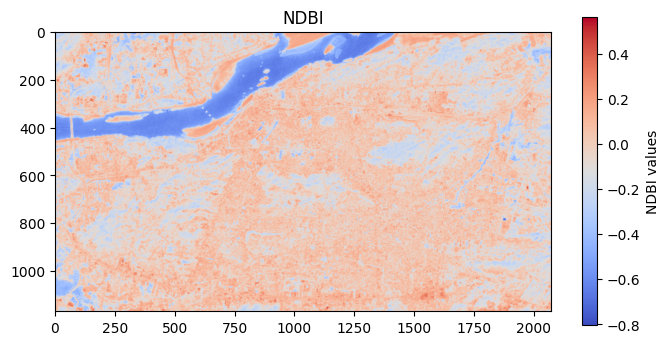

In [29]:
ndbi = (b11-b8)/(b11+b8)
plt.figure(figsize=(8,4))
plt.imshow(ndbi, cmap = 'coolwarm')
plt.title("NDBI")
plt.colorbar(label="NDBI values")
plt.show()
#

**Extraction of Built-Up Contents**

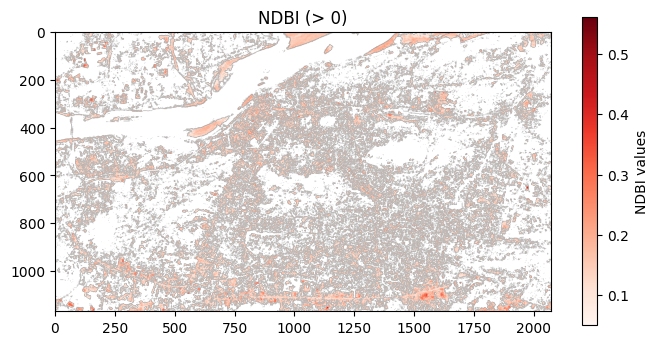

In [37]:
ndbi_masked = np.ma.masked_less_equal(ndbi, 0.05)
# 0.05 taken because Red Settlements are starting to show up after that range

plt.figure(figsize=(8, 4))
# imshow automatically handles masked arrays by making them transparent
plt.imshow(ndbi_masked, cmap='Reds')
plt.title("NDBI (> 0)")
plt.colorbar(label="NDBI values")
plt.show()

**Statistics:**

In [39]:
ndbi_mask = ndbi > 0

# 3. Count how many pixels meet the condition (True evaluates to 1, False to 0)
valid_pixel_count = np.sum(ndbi_mask)

# 4. Calculate the area
single_pixel_area = 10 * 10  # 10m * 10m = 100 m² for Sentinel-2
area_sq_meters = valid_pixel_count * single_pixel_area
area_hectares = area_sq_meters / 10000
area_sq_kilometers = area_sq_meters / 1e6

# 5. Print the results clearly
print(f"--- Area Calculation for NDBI > 0 ---")
print(f"Valid Pixels     : {valid_pixel_count:,}")
print(f"Square Meters    : {area_sq_meters:,.2f} m²")
print(f"Hectares         : {area_hectares:,.2f} ha")
print(f"Square Kilometers: {area_sq_kilometers:,.4f} km²")

--- Area Calculation for NDBI > 0 ---
Valid Pixels     : 1,075,014
Square Meters    : 107,501,400.00 m²
Hectares         : 10,750.14 ha
Square Kilometers: 107.5014 km²




---



# False Color Composite

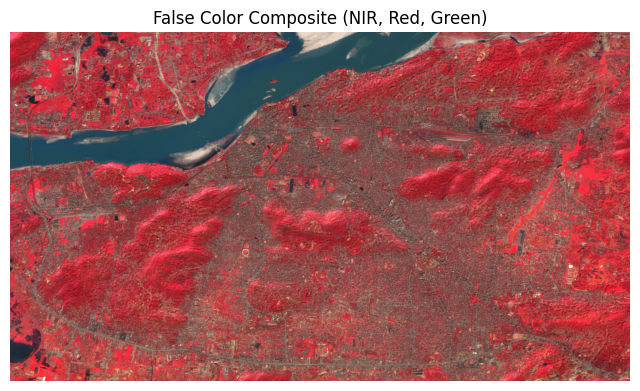

In [40]:
fcc_stack = np.dstack((b8, b4, b3)) # np.dstack: converting 2D to 3D arrays

#Contrast Stretching
min_val = 0
max_val = 3000

#Normalize 0 & 1
fcc_normalized = np.clip((fcc_stack - min_val) / (max_val - min_val), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(fcc_normalized)
plt.title('False Color Composite (NIR, Red, Green)')
plt.axis('off')
plt.show()


# True Color Composite

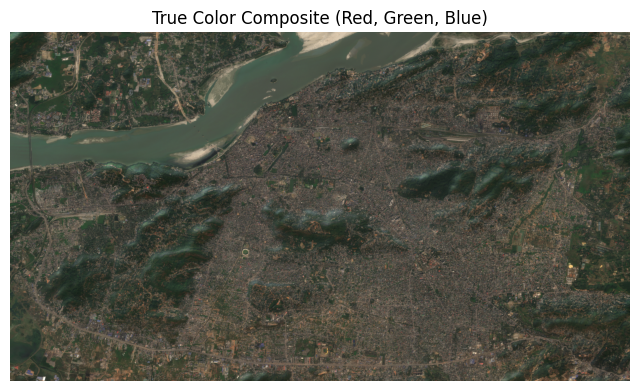

In [41]:
tcc_stack = np.dstack((b4, b3, b2)) # np.dstack: converting 2D to 3D arrays

#Contrast Stretching
min_val = 0
max_val = 3000

#Normalize 0 & 1
tcc_normalized = np.clip((tcc_stack - min_val) / (max_val - min_val), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(tcc_normalized)
plt.title('True Color Composite (Red, Green, Blue)')
plt.axis('off')
plt.show()




---



***Plotting all Indices Together for Comparison of Areas.***

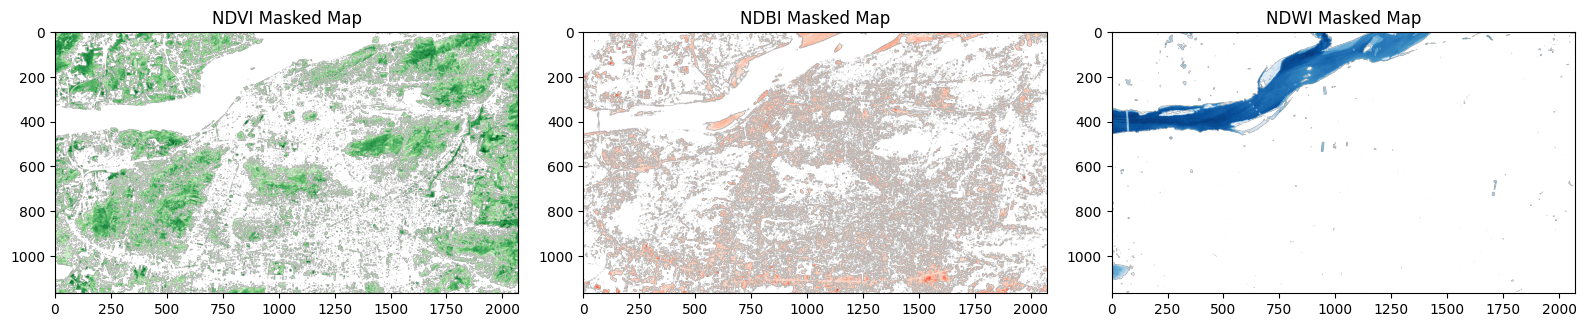

In [26]:
# 1. Create the side-by-side layout
fig, (ax3, ax4, ax5) = plt.subplots(1, 3, figsize=(16, 8))

# 2. Plot on the first (left) axis directly
ax3.imshow(ndvi_masked, cmap='Greens')
ax3.set_title("NDVI Masked Map")

# 3. Plot on the second (right) axis directly
ax4.imshow(ndbi_masked, cmap='Reds')
ax4.set_title("NDBI Masked Map")

ax5.imshow(ndwi_masked, cmap='Blues')
ax5.set_title("NDWI Masked Map")

plt.tight_layout()
plt.show()


# ***Overlapping all the Indices Together :***

*We get a beautiful Map.*

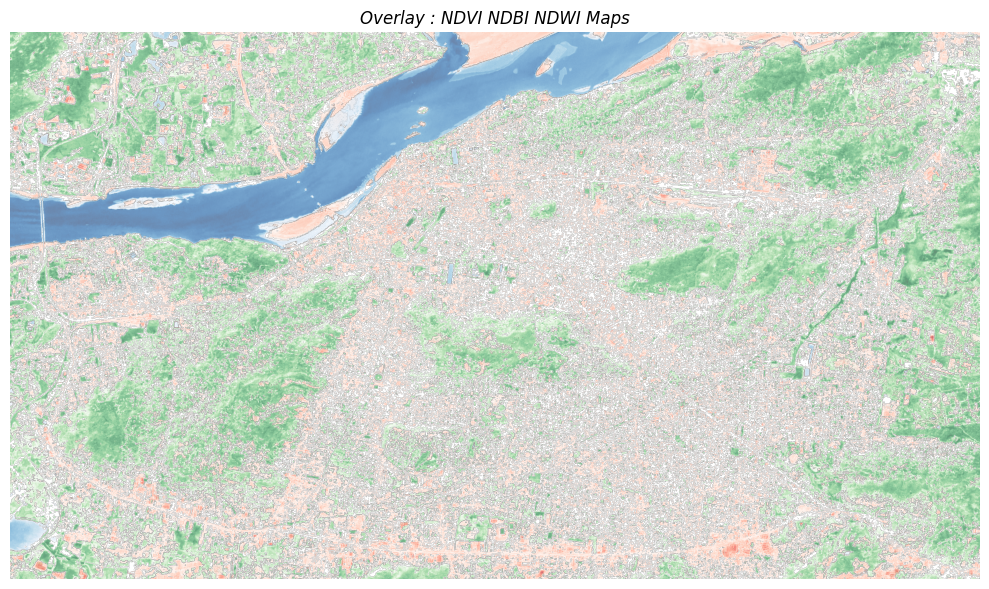

In [52]:
# 1. Create a single figure and axis (instead of 1, 3)
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Plot each layer on the same axis with transparency (alpha)
# Adjust alpha values (0 to 1) depending on how much blending you want
ax.imshow(ndvi_masked, cmap='Greens', alpha=0.6, label='NDVI')
ax.imshow(ndbi_masked, cmap='Reds', alpha=0.6, label='NDBI')
ax.imshow(ndwi_masked, cmap='Blues', alpha=0.6, label='NDWI')

# 3. Add title and clean up
ax.set_title("Overlay : NDVI NDBI NDWI Maps", fontstyle="italic")
ax.axis('off') # Optional: turns off the axis ticks/borders
ax.get_legend_handles_labels()


plt.tight_layout()
plt.show()

**Higher-Contrast Image -**

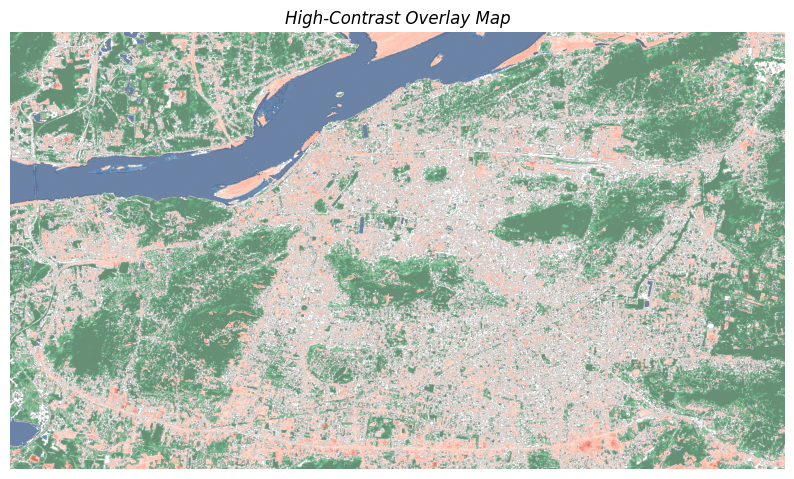

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))

# Example: If your NDVI data mostly ranges from 0.1 to 0.7,
# forcing vmin=0.2 and vmax=0.6 will increase contrast for that range.
ax.imshow(ndvi_masked, cmap='Greens', vmin=0.2, vmax=0.6, alpha=0.6, label='NDVI')
ax.imshow(ndbi_masked, cmap='Reds', vmin=0, vmax=0.5, alpha=0.6, label='NDBI')
ax.imshow(ndwi_masked, cmap='Blues', vmin=-0.3, vmax=0.1, alpha=0.6, label='NDWI')

ax.set_title("High-Contrast Overlay Map", fontstyle="italic")
ax.axis('off')

plt.show()